# Assignment 2 - 46770 Integrated Energy Grids  
February 2026

In this second part of the course project, the analysis extends the one-node German system with a global CO$_2$ constraint and then introduces a methane transport layer for the interconnected model.

The notebook follows the same style as Assignment 1: data loading first, then model construction, optimisation, and plots for each section.


In [ ]:
from pathlib import Path
import pandas as pd
pd.options.future.infer_string = False
import matplotlib.pyplot as plt
import pypsa
import re
import math
import numpy as np
import json
import time
import requests

BASE_DIR: c:\Users\Fernando\OneDrive - Danmarks Tekniske Universitet\Escritorio\MscSustainableEnergy\4 Semester\46770 Integrated Energy Grids\Assignment\Integrated_Energy_Grids\Modules
DATA_DIR: c:\Users\Fernando\OneDrive - Danmarks Tekniske Universitet\Escritorio\MscSustainableEnergy\4 Semester\46770 Integrated Energy Grids\Assignment\Integrated_Energy_Grids\data
PLOTS_DIR: c:\Users\Fernando\OneDrive - Danmarks Tekniske Universitet\Escritorio\MscSustainableEnergy\4 Semester\46770 Integrated Energy Grids\Assignment\Integrated_Energy_Grids\Plots
GENERATION_FILE exists: True
LOAD_FILE exists: True


## Data
### Paths


In [ ]:
BASE_DIR = Path.cwd()
DATA_DIR = BASE_DIR.parent / "data"
PLOTS_DIR = BASE_DIR.parent / "Plots"
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

GENERATION_FILE = DATA_DIR / "energy-charts_Total_net_electricity_generation_in_Germany_in_2024.csv"
LOAD_FILE = DATA_DIR / "energy-charts_Total_net_electricity_generation_in_Germany_in_2024_load.csv"
print("BASE_DIR:", BASE_DIR)
print("DATA_DIR:", DATA_DIR)
print("PLOTS_DIR:", PLOTS_DIR)
print("GENERATION_FILE exists:", GENERATION_FILE.exists())
print("LOAD_FILE exists:", LOAD_FILE.exists())

### Loading and cleaning


In [2]:
print("Reading files...")
print("Generation file:", GENERATION_FILE)
print("Load file:", LOAD_FILE)

gen_raw = pd.read_csv(GENERATION_FILE)
load_raw = pd.read_csv(LOAD_FILE)

gen_raw.columns = [str(c).strip() for c in gen_raw.columns]
load_raw.columns = [str(c).strip() for c in load_raw.columns]

print("\nGeneration columns:")
print(gen_raw.columns.tolist())

print("\nLoad columns:")
print(load_raw.columns.tolist())

GENERATION_TIME_COL = gen_raw.columns[0]
LOAD_TIME_COL = load_raw.columns[0]

WIND_OFFSHORE_COL = "Wind offshore"
WIND_ONSHORE_COL = "Wind onshore"
SOLAR_COL = "Solar"
LOAD_COL = "Load"


def parse_time(series):
    try:
        return pd.to_datetime(series, errors="coerce", utc=True, format="mixed")
    except Exception:
        return pd.to_datetime(series, errors="coerce", utc=True)


def parse_number(series):
    s = series.astype(str).str.strip()
    s = s.str.replace("\u202f", "", regex=False)
    s = s.str.replace("\xa0", "", regex=False)
    s = s.str.replace(" ", "", regex=False)
    s = s.str.replace(",", "", regex=False)
    return pd.to_numeric(s, errors="coerce")


gen_raw[GENERATION_TIME_COL] = parse_time(gen_raw[GENERATION_TIME_COL])
load_raw[LOAD_TIME_COL] = parse_time(load_raw[LOAD_TIME_COL])

gen_raw = gen_raw.dropna(subset=[GENERATION_TIME_COL]).copy()
load_raw = load_raw.dropna(subset=[LOAD_TIME_COL]).copy()

gen_raw = gen_raw.set_index(GENERATION_TIME_COL)
load_raw = load_raw.set_index(LOAD_TIME_COL)

if getattr(gen_raw.index, "tz", None) is not None:
    gen_raw.index = gen_raw.index.tz_convert("Europe/Berlin").tz_localize(None)
    gen_raw.index.name = "Date"

if getattr(load_raw.index, "tz", None) is not None:
    load_raw.index = load_raw.index.tz_convert("Europe/Berlin").tz_localize(None)
    load_raw.index.name = "Date"

gen = pd.DataFrame(index=gen_raw.index)
gen["wind_offshore"] = parse_number(gen_raw[WIND_OFFSHORE_COL])
gen["wind_onshore"] = parse_number(gen_raw[WIND_ONSHORE_COL])
gen["solar"] = parse_number(gen_raw[SOLAR_COL])

load = pd.DataFrame(index=load_raw.index)
load["load"] = parse_number(load_raw[LOAD_COL])

df = gen.join(load, how="inner")
df = df.dropna().copy()
df = df.groupby(df.index).mean()
df = df[(df.index >= "2024-01-01") & (df.index < "2025-01-01")].copy()

# Convert 15-minute data to hourly averages
df = df.resample("1h").mean()
df = df.interpolate(method="time")

# Remove Feb 29 so the year has 8760 hours
df = df[~((df.index.month == 2) & (df.index.day == 29))].copy()

print("\nFirst rows:")
print(df.head())

print("\nShape:")
print(df.shape)

Reading files...
Generation file: c:\Users\Fernando\OneDrive - Danmarks Tekniske Universitet\Escritorio\MscSustainableEnergy\4 Semester\46770 Integrated Energy Grids\Assignment\Integrated_Energy_Grids\data\energy-charts_Total_net_electricity_generation_in_Germany_in_2024.csv
Load file: c:\Users\Fernando\OneDrive - Danmarks Tekniske Universitet\Escritorio\MscSustainableEnergy\4 Semester\46770 Integrated Energy Grids\Assignment\Integrated_Energy_Grids\data\energy-charts_Total_net_electricity_generation_in_Germany_in_2024_load.csv

Generation columns:
['Date (GMT+1)', 'Wind offshore', 'Wind onshore', 'Solar']

Load columns:
['Date (GMT+1)', 'Load']

First rows:
                     wind_offshore  wind_onshore  solar       load
Date                                                              
2024-01-01 00:00:00       5682.425     29106.525    0.0  42896.250
2024-01-01 01:00:00       5348.775     29017.375    0.0  41452.550
2024-01-01 02:00:00       5191.500     29096.325    0.0  40416.10

### Inputs for sections G,H and J

These sections reuse the multi-country preprocessing we used Assignment 1 with the API calls to energy charts


In [ ]:
API_BASE = "https://api.energy-charts.info"
START_2024 = "2024-01-01"
END_2024 = "2024-12-31"
CACHE_DIR = DATA_DIR / "energy_charts_cache"
CACHE_DIR.mkdir(parents=True, exist_ok=True)

COUNTRY_CODES = {
    "Germany": "de",
    "Belgium": "be",
    "France": "fr",
    "Netherlands": "nl",
}

NETWORK_EDGES = [
    ("Germany", "Belgium"),
    ("Germany", "France"),
    ("Germany", "Netherlands"),
    ("Belgium", "France"),
    ("Belgium", "Netherlands"),
]


def slugify(text: str) -> str:
    text = text.lower().strip()
    text = text.replace("-", " ").replace("/", " ")
    text = re.sub(r"[^a-z0-9]+", "_", text)
    text = re.sub(r"_+", "_", text).strip("_")
    return text


def _cache_key(endpoint: str, **params) -> Path:
    parts = [endpoint] + [f"{key}={params[key]}" for key in sorted(params)]
    safe_name = "__".join(parts).replace("/", "_").replace(":", "_")
    return CACHE_DIR / f"{safe_name}.json"


def ec_get(endpoint: str, use_cache: bool = True, **params):
    cache_file = _cache_key(endpoint, **params)

    if use_cache and cache_file.exists():
        with open(cache_file, "r", encoding="utf-8") as file:
            return json.load(file)

    url = f"{API_BASE}/{endpoint}"
    max_retries = 6
    base_wait_seconds = 5

    for attempt in range(max_retries):
        response = requests.get(url, params=params, timeout=60)

        if response.status_code == 429:
            retry_after = response.headers.get("Retry-After")
            sleep_time = int(retry_after) if retry_after is not None else base_wait_seconds * (attempt + 1)
            print(f"Rate limited for {endpoint} with {params}. Retrying in {sleep_time}s...")
            time.sleep(sleep_time)
            continue

        response.raise_for_status()
        data = response.json()

        if use_cache:
            with open(cache_file, "w", encoding="utf-8") as file:
                json.dump(data, file)

        time.sleep(1.0)
        return data

    raise RuntimeError(f"Failed to fetch Energy Charts endpoint '{endpoint}' after {max_retries} retries.")


def get_public_power_df(country_code: str, start=START_2024, end=END_2024) -> pd.DataFrame:
    data_json = ec_get("public_power", country=country_code, start=start, end=end)
    timestamps = pd.to_datetime(data_json["unix_seconds"], unit="s", utc=True)
    data = {slugify(item["name"]): item["data"] for item in data_json["production_types"]}
    df = pd.DataFrame(data, index=timestamps).sort_index()
    df = df.resample("1h").mean()
    df.index = df.index.tz_convert(None)
    return df


def get_installed_power_2024(country_code: str) -> pd.Series:
    data_json = ec_get("installed_power", country=country_code, time_step="yearly")
    years = [str(t) for t in data_json["time"]]
    year_position = years.index("2024")
    values = {slugify(item["name"]): item["data"][year_position] for item in data_json["production_types"]}
    return pd.Series(values, dtype=float) * 1000.0


def get_cbpf_df(country_code: str, start=START_2024, end=END_2024) -> pd.DataFrame:
    data_json = ec_get("cbpf", country=country_code, start=start, end=end)
    timestamps = pd.to_datetime(data_json["unix_seconds"], unit="s", utc=True)
    data = {slugify(item["name"]): item["data"] for item in data_json["countries"]}
    df = pd.DataFrame(data, index=timestamps).sort_index()
    df = df.resample("1h").mean()
    df.index = df.index.tz_convert(None)
    return df


def find_best_matching_key(keys, patterns):
    slugged_keys = {slugify(k): k for k in keys}

    for pattern in patterns:
        pattern_slug = slugify(pattern)
        if pattern_slug in slugged_keys:
            return slugged_keys[pattern_slug]

    for pattern in patterns:
        pattern_slug = slugify(pattern)
        for key_slug, original_key in slugged_keys.items():
            if pattern_slug in key_slug:
                return original_key

    return None


def extract_installed_capacities(installed_power_series: pd.Series) -> dict:
    keys = list(installed_power_series.index)
    mapping = {
        "wind_onshore": ["wind_onshore", "onshore"],
        "wind_offshore": ["wind_offshore", "offshore"],
        "solar": ["solar", "pv", "photovoltaic", "photovoltaics"],
        "gas": ["fossil_gas", "gas"],
    }

    capacities = {}
    for tech, patterns in mapping.items():
        key = find_best_matching_key(keys, patterns)
        capacities[tech] = float(installed_power_series[key]) if key is not None else 0.0

    return capacities


def extract_generation_bundle(public_power_df: pd.DataFrame) -> dict:
    columns = list(public_power_df.columns)

    load_key = find_best_matching_key(columns, ["load"])
    if load_key is None:
        raise ValueError(f"Load column not found. Available columns: {columns}")

    solar_key = find_best_matching_key(columns, ["solar", "pv", "photovoltaic", "photovoltaics"])
    wind_onshore_key = find_best_matching_key(columns, ["wind_onshore", "onshore"])
    wind_offshore_key = find_best_matching_key(columns, ["wind_offshore", "offshore"])
    gas_key = find_best_matching_key(columns, ["fossil_gas", "gas"])

    load_series = pd.to_numeric(public_power_df[load_key], errors="coerce").fillna(0.0)
    solar = pd.to_numeric(public_power_df[solar_key], errors="coerce").fillna(0.0) if solar_key else pd.Series(0.0, index=public_power_df.index)
    wind_onshore = pd.to_numeric(public_power_df[wind_onshore_key], errors="coerce").fillna(0.0) if wind_onshore_key else pd.Series(0.0, index=public_power_df.index)
    wind_offshore = pd.to_numeric(public_power_df[wind_offshore_key], errors="coerce").fillna(0.0) if wind_offshore_key else pd.Series(0.0, index=public_power_df.index)
    gas = pd.to_numeric(public_power_df[gas_key], errors="coerce").fillna(0.0) if gas_key else pd.Series(0.0, index=public_power_df.index)

    generation_columns = [col for col in public_power_df.columns if col != load_key]
    total_generation = public_power_df[generation_columns].apply(pd.to_numeric, errors="coerce").fillna(0.0).sum(axis=1)
    residual_generation = (total_generation - solar - wind_onshore - wind_offshore - gas).clip(lower=0.0)

    return {
        "load": load_series.clip(lower=0.0),
        "solar": solar.clip(lower=0.0),
        "wind_onshore": wind_onshore.clip(lower=0.0),
        "wind_offshore": wind_offshore.clip(lower=0.0),
        "gas": gas.clip(lower=0.0),
        "residual_generation": residual_generation,
    }


def get_observed_line_capacity_mw(country_a: str, country_b: str) -> float:
    code_a = COUNTRY_CODES[country_a]
    code_b = COUNTRY_CODES[country_b]

    df_a = get_cbpf_df(code_a)
    col_a = find_best_matching_key(df_a.columns, [country_b])
    if col_a is not None:
        return math.ceil(float(df_a[col_a].abs().max()) * 1000.0)

    df_b = get_cbpf_df(code_b)
    col_b = find_best_matching_key(df_b.columns, [country_a])
    if col_b is not None:
        return math.ceil(float(df_b[col_b].abs().max()) * 1000.0)

    raise ValueError(f"No cross-border flow series found for {country_a} and {country_b}")


country_data = {}

for country_name, country_code in COUNTRY_CODES.items():
    public_power = get_public_power_df(country_code)
    installed_power = get_installed_power_2024(country_code)

    observed = extract_generation_bundle(public_power)
    capacities_mw = extract_installed_capacities(installed_power)

    cf_onshore = (
        observed["wind_onshore"] / capacities_mw["wind_onshore"]
        if capacities_mw["wind_onshore"] > 0
        else pd.Series(0.0, index=public_power.index)
    )
    cf_offshore = (
        observed["wind_offshore"] / capacities_mw["wind_offshore"]
        if capacities_mw["wind_offshore"] > 0
        else pd.Series(0.0, index=public_power.index)
    )
    cf_solar = (
        observed["solar"] / capacities_mw["solar"]
        if capacities_mw["solar"] > 0
        else pd.Series(0.0, index=public_power.index)
    )

    country_data[country_name] = {
        "load": observed["load"],
        "gas_dispatch": observed["gas"],
        "residual_generation": observed["residual_generation"],
        "cf_onshore": cf_onshore.clip(lower=0, upper=1),
        "cf_offshore": cf_offshore.clip(lower=0, upper=1),
        "cf_solar": cf_solar.clip(lower=0, upper=1),
        "capacities_mw": capacities_mw,
    }

snapshots = country_data["Germany"]["load"].index

for country_name in country_data:
    for variable_name in [
        "load",
        "gas_dispatch",
        "residual_generation",
        "cf_onshore",
        "cf_offshore",
        "cf_solar",
    ]:
        series = country_data[country_name][variable_name]
        series = series.reindex(snapshots)
        series = series.interpolate().ffill().bfill()
        country_data[country_name][variable_name] = series

line_capacities_mw = {}
for bus0, bus1 in NETWORK_EDGES:
    line_capacities_mw[(bus0, bus1)] = get_observed_line_capacity_mw(bus0, bus1)

print("Installed capacities in 2024 (MW):")
for country_name in country_data:
    print(f"\n{country_name}")
    print(pd.Series(country_data[country_name]["capacities_mw"]))

print("\nInterconnector capacities used in the model (MW):")
for edge, value in line_capacities_mw.items():
    print(f"{edge}: {value}")

# Section F
Sensitivity of a global $CO_2$ constraint based on the single-country - this is the one-node model from Assignment 1.


In [3]:
# Capacity factors for the one-node model
# 2024 observed maxima are used as simple capacity proxies.

installed_capacity = {
    "wind_onshore": df["wind_onshore"].max(),
    "wind_offshore": df["wind_offshore"].max(),
    "solar": df["solar"].max(),
}

df_model = pd.DataFrame(index=df.index)
df_model["load"] = df["load"]
df_model["cf_onshore"] = (df["wind_onshore"] / installed_capacity["wind_onshore"]).clip(lower=0, upper=1)
df_model["cf_offshore"] = (df["wind_offshore"] / installed_capacity["wind_offshore"]).clip(lower=0, upper=1)
df_model["cf_solar"] = (df["solar"] / installed_capacity["solar"]).clip(lower=0, upper=1)

print(df_model.head())


                          load  cf_onshore  cf_offshore  cf_solar
Date                                                             
2024-01-01 00:00:00  42896.250    0.640509     0.767742  0.000000
2024-01-01 01:00:00  41452.550    0.638548     0.722663  0.000000
2024-01-01 02:00:00  40416.100    0.640285     0.701414  0.000000
2024-01-01 03:00:00  39642.625    0.628686     0.631867  0.000000
2024-01-01 04:00:00  39247.775    0.627222     0.600134  0.000038


In [4]:
def annuity(n, r):
    if r > 0:
        return r / (1 - (1 + r) ** (-n))
    return 1 / n


def pick_solver():
    # Prefer Gurobi when available, otherwise fall back to HiGHS.
    for solver in ["gurobi", "highs"]:
        try:
            return solver
        except Exception:
            pass
    return "highs"

### Network Build
**One-node Germany**


In [5]:
# Build the one-node Germany model
# - No exogenous CO2 price in gas marginal cost
# - CO2 signal comes from the global constraint

def build_germany_one_node_model(df_input):
    network = pypsa.Network()
    network.set_snapshots(df_input.index)

    network.add("Bus", "electricity bus")

    network.add(
        "Load",
        "load",
        bus="electricity bus",
        p_set=df_input["load"].values
    )

    # Carriers
    network.add("Carrier", "onshorewind")
    network.add("Carrier", "offshorewind")
    network.add("Carrier", "solar")
    network.add("Carrier", "battery")
    network.add("Carrier", "gas", co2_emissions=0.19)  # tCO2/MWh_th

    # Techno-economic assumptions

    r = 0.07  # discount rate

    capex_onshore = 910000
    fom_onshore = 0.033
    lifetime_onshore = 30

    capex_offshore = 2506000 
    fom_offshore = 0.033
    lifetime_offshore = 25

    capex_solar = 425000
    fom_solar = 0.03
    lifetime_solar = 25

    capex_gas = 560000
    fom_gas = 0.033
    lifetime_gas = 25

    capital_cost_onshore = annuity(lifetime_onshore, r) * capex_onshore * (1 + fom_onshore)
    capital_cost_offshore = annuity(lifetime_offshore, r) * capex_offshore * (1 + fom_offshore)
    capital_cost_solar = annuity(lifetime_solar, r) * capex_solar * (1 + fom_solar)
    capital_cost_gas = annuity(lifetime_gas, r) * capex_gas * (1 + fom_gas)

    fuel_cost_gas = 21.6
    efficiency_gas = 0.39

    # No exogenous CO2 price here; the CO2 signal comes from the global constraint.
    marginal_cost_gas = fuel_cost_gas / efficiency_gas

    # Generators
    network.add(
        "Generator",
        "onshorewind",
        bus="electricity bus",
        carrier="onshorewind",
        p_nom_extendable=True,
        capital_cost=capital_cost_onshore,
        marginal_cost=0.0,
        p_max_pu=df_input["cf_onshore"].values
    )

    network.add(
        "Generator",
        "offshorewind",
        bus="electricity bus",
        carrier="offshorewind",
        p_nom_extendable=True,
        capital_cost=capital_cost_offshore,
        marginal_cost=0.0,
        p_max_pu=df_input["cf_offshore"].values
    )

    network.add(
        "Generator",
        "solar",
        bus="electricity bus",
        carrier="solar",
        p_nom_extendable=True,
        capital_cost=capital_cost_solar,
        marginal_cost=0.0,
        p_max_pu=df_input["cf_solar"].values
    )

    network.add(
        "Generator",
        "gas",
        bus="electricity bus",
        carrier="gas",
        p_nom_extendable=True,
        capital_cost=capital_cost_gas,
        marginal_cost=marginal_cost_gas,
        efficiency=efficiency_gas
    )

    # Battery
    n_bess = 15
    hmax = 6
    eta_ch = 0.90
    eta_dis = 0.90
    c_energy = 144600
    c_inverter = 310000
    fom_bess = 0.03

    battery_power_cost = annuity(n_bess, r) * (c_energy * hmax + c_inverter) * (1 + fom_bess)

    network.add(
        "StorageUnit",
        "battery",
        bus="electricity bus",
        carrier="battery",
        p_nom_extendable=True,
        max_hours=hmax,
        efficiency_store=eta_ch,
        efficiency_dispatch=eta_dis,
        cyclic_state_of_charge=True,
        capital_cost=battery_power_cost
    )

    return network


**Solve one case**


In [6]:
def solve_case(df_input, co2_cap_tonnes=None, solver_name=None):
    if solver_name is None:
        solver_name = pick_solver()

    network = build_germany_one_node_model(df_input)

    if co2_cap_tonnes is not None:
        network.add(
            "GlobalConstraint",
            "co2_limit",
            type="primary_energy",
            carrier_attribute="co2_emissions",
            sense="<=",
            constant=co2_cap_tonnes
        )

    def _to_object_index(idx):
        if hasattr(idx, "dtype") and str(idx.dtype).startswith("string"):
            return idx.astype("object")
        return idx

    # Keep string-like indices as object dtype to avoid xarray compatibility issues.
    for component in network.components.values():
        static = getattr(network, component.list_name, None)
        if static is None or static.empty:
            continue

        static.index = _to_object_index(static.index)
        static.columns = _to_object_index(static.columns)

        for col in static.columns:
            if str(static[col].dtype).startswith("string"):
                static[col] = static[col].astype("object")

    network.optimize(solver_name=solver_name)

    annual_generation = network.generators_t.p.sum()

    capacities = network.generators.p_nom_opt.copy()
    if "battery" in network.storage_units.index:
        capacities["battery"] = network.storage_units.at["battery", "p_nom_opt"]

    gas_generation = network.generators_t.p["gas"].sum() if "gas" in network.generators_t.p.columns else 0.0
    gas_efficiency = network.generators.at["gas", "efficiency"]
    total_emissions = gas_generation / gas_efficiency * network.carriers.at["gas", "co2_emissions"]

    mu_co2 = np.nan
    if "co2_limit" in network.global_constraints.index:
        mu_co2 = -float(network.global_constraints.at["co2_limit", "mu"])

    return {
        "network": network,
        "annual_generation": annual_generation,
        "capacities": capacities,
        "total_emissions": total_emissions,
        "mu_co2": mu_co2
    }


### Baseline Run


In [7]:
SOLVER = "highs"  

baseline = solve_case(df_model, co2_cap_tonnes=None, solver_name=SOLVER)
baseline_emissions = baseline["total_emissions"]

print("Baseline total CO2 emissions [tCO2]:", baseline_emissions)
print("\nBaseline capacities [MW]:")
print(baseline["capacities"])

Index(['electricity bus'], dtype='object', name='name')
INFO:linopy.model: Solve problem using Highs solver
INFO:linopy.io:Writing objective.
Writing continuous variables.: 100%|██████████| 6/6 [00:00<00:00, 135.05it/s]
INFO:linopy.io: Writing time: 0.85s
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 61325 primals, 140165 duals
Objective: 2.39e+10
Solver model: available
Solver message: Optimal

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-ext-p-lower, Generator-ext-p-upper, StorageUnit-ext-p_dispatch-lower, StorageUnit-ext-p_dispatch-upper, StorageUnit-ext-p_store-lower, StorageUnit-ext-p_store-upper, StorageUnit-ext-state_of_charge-lower, StorageUnit-ext-state_of_charge-upper, StorageUnit-energy_balance were not assigned to the network.


Baseline total CO2 emissions [tCO2]: 85372290.44312114

Baseline capacities [MW]:
name
onshorewind     102874.679310
offshorewind        -0.000000
solar            76580.584597
gas              71422.667013
battery             -0.000000
Name: p_nom_opt, dtype: float64


### Sensitivity Runs


In [8]:
cap_shares = [1.00, 0.75, 0.50, 0.25, 0.10, 0.05, 0.00]
results = []

for share in cap_shares:
    co2_cap = share * baseline_emissions
    case = solve_case(df_model, co2_cap_tonnes=co2_cap, solver_name=SOLVER)

    results.append({
        "co2_cap_share": share,
        "co2_cap_tonnes": co2_cap,
        "co2_emissions_tonnes": case["total_emissions"],
        "mu_co2_eur_per_tco2": case["mu_co2"],
        "cap_onshore_mw": case["capacities"].get("onshorewind", 0.0),
        "cap_offshore_mw": case["capacities"].get("offshorewind", 0.0),
        "cap_solar_mw": case["capacities"].get("solar", 0.0),
        "cap_gas_mw": case["capacities"].get("gas", 0.0),
        "cap_battery_mw": case["capacities"].get("battery", 0.0),
        "gen_onshore_mwh": case["annual_generation"].get("onshorewind", 0.0),
        "gen_offshore_mwh": case["annual_generation"].get("offshorewind", 0.0),
        "gen_solar_mwh": case["annual_generation"].get("solar", 0.0),
        "gen_gas_mwh": case["annual_generation"].get("gas", 0.0),
    })

results_df = pd.DataFrame(results)
results_df.to_csv(PLOTS_DIR / "section_f_co2_sensitivity_results.csv", index=False)

print(results_df)

Index(['electricity bus'], dtype='object', name='name')
INFO:linopy.model: Solve problem using Highs solver
INFO:linopy.io:Writing objective.
Writing continuous variables.: 100%|██████████| 6/6 [00:00<00:00, 173.38it/s]
INFO:linopy.io: Writing time: 0.51s
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 61325 primals, 140166 duals
Objective: 2.39e+10
Solver model: available
Solver message: Optimal

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-ext-p-lower, Generator-ext-p-upper, StorageUnit-ext-p_dispatch-lower, StorageUnit-ext-p_dispatch-upper, StorageUnit-ext-p_store-lower, StorageUnit-ext-p_store-upper, StorageUnit-ext-state_of_charge-lower, StorageUnit-ext-state_of_charge-upper, StorageUnit-energy_balance were not assigned to the network.
Index(['electricity bus'], dtype='object', name='name')
INFO:linopy.model: Solve problem using Highs solver
INFO:linopy.io:Writing objective.
Writing continuous 

   co2_cap_share  co2_cap_tonnes  co2_emissions_tonnes  mu_co2_eur_per_tco2  \
0           1.00    8.537229e+07          8.537229e+07             0.000000   
1           0.75    6.402922e+07          6.402922e+07            54.673245   
2           0.50    4.268615e+07          4.268615e+07           144.191470   
3           0.25    2.134307e+07          2.134307e+07           377.357522   
4           0.10    8.537229e+06          8.537229e+06          1399.892326   
5           0.05    4.268615e+06          4.268615e+06          4740.395055   
6           0.00    0.000000e+00          0.000000e+00         33224.943413   

   cap_onshore_mw  cap_offshore_mw   cap_solar_mw    cap_gas_mw  \
0   102874.679310        -0.000000   76580.584597  71422.667013   
1   130547.727969        -0.000000   91369.443364  66980.528341   
2   165618.235370        -0.000000  115894.859650  60765.765206   
3   184939.629975        -0.000000  170335.889549  54471.100204   
4   254585.536545        -0.0000

### Plots


#### Helper functions for plotting

In [30]:
def choose_scale(values, unit_family):
    values = np.asarray(values, dtype=float)
    vmax = np.nanmax(np.abs(values)) if values.size else 0.0

    if unit_family == "power_mw":
        choices = [(1.0, "MW"), (1e3, "GW"), (1e6, "TW")]
    elif unit_family == "energy_mwh":
        choices = [(1.0, "MWh"), (1e3, "GWh"), (1e6, "TWh")]
    elif unit_family == "currency":
        choices = [(1.0, "EUR"), (1e3, "kEUR"), (1e6, "mEUR")]
    else:
        return 1.0, ""

    scale, label = choices[0]
    for cand_scale, cand_label in choices:
        if vmax >= cand_scale:
            scale, label = cand_scale, cand_label

    return scale, label


def style_axes(ax):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.set_axisbelow(True)
    ax.grid(True, linestyle="--", alpha=0.3)
    ax.tick_params(axis="both", labelsize=13)

#### Optimal capacities vs CO2 cap

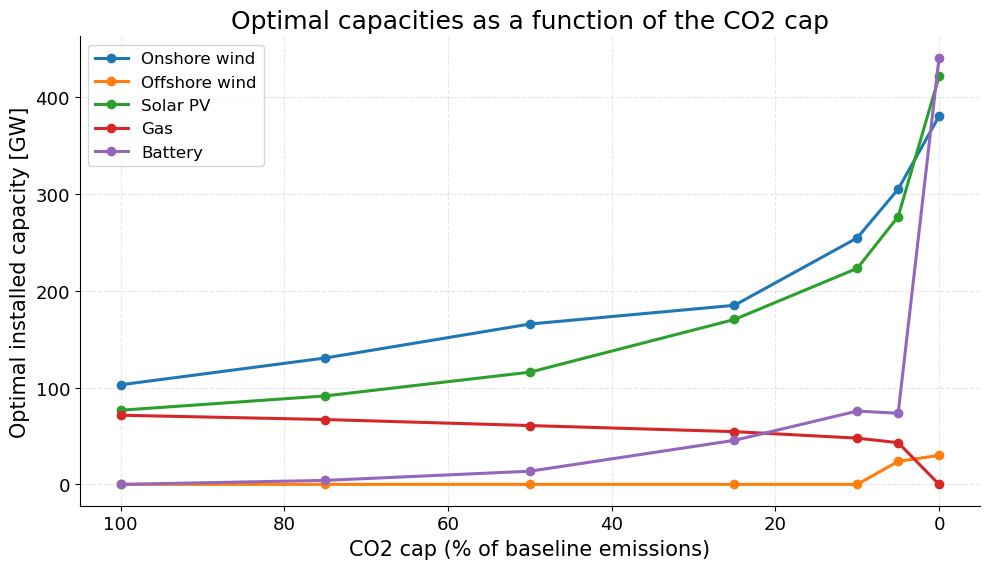

In [29]:
cap_columns = {
    "Onshore wind": results_df["cap_onshore_mw"],
    "Offshore wind": results_df["cap_offshore_mw"],
    "Solar PV": results_df["cap_solar_mw"],
    "Gas": results_df["cap_gas_mw"],
    "Battery": results_df["cap_battery_mw"],
}
cap_scale, cap_unit = choose_scale(pd.concat(list(cap_columns.values())), "power_mw")

fig, ax = plt.subplots(figsize=(10, 5.8))
for label, series in cap_columns.items():
    ax.plot(results_df["co2_cap_share"] * 100, series / cap_scale, marker="o", linewidth=2.2, markersize=6, label=label)

ax.invert_xaxis()
ax.set_xlabel("CO2 cap (% of baseline emissions)", fontsize=15)
ax.set_ylabel(f"Optimal installed capacity [{cap_unit}]", fontsize=15)
ax.set_title("Optimal capacities as a function of the CO2 cap", fontsize=18)
style_axes(ax)
ax.legend(fontsize=12, frameon=True)
fig.tight_layout()
fig.savefig(PLOTS_DIR / "section_f_capacities_vs_co2_cap.png", dpi=300)
plt.show()


#### Generation mix vs CO2 cap

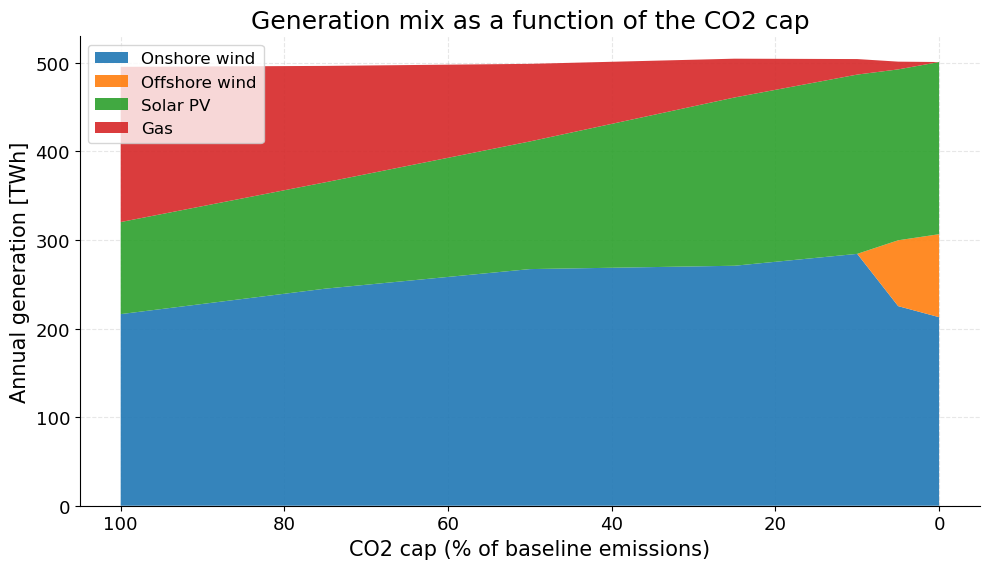

In [31]:
gen_plot = results_df.sort_values("co2_cap_share", ascending=False)
gen_columns = {
    "Onshore wind": gen_plot["gen_onshore_mwh"],
    "Offshore wind": gen_plot["gen_offshore_mwh"],
    "Solar PV": gen_plot["gen_solar_mwh"],
    "Gas": gen_plot["gen_gas_mwh"],
}
gen_scale, gen_unit = choose_scale(pd.concat(list(gen_columns.values())), "energy_mwh")

fig, ax = plt.subplots(figsize=(10, 5.8))
ax.stackplot(
    gen_plot["co2_cap_share"] * 100,
    *[series / gen_scale for series in gen_columns.values()],
    labels=list(gen_columns.keys()),
    alpha=0.9,
)
ax.invert_xaxis()
ax.set_xlabel("CO2 cap (% of baseline emissions)", fontsize=15)
ax.set_ylabel(f"Annual generation [{gen_unit}]", fontsize=15)
ax.set_title("Generation mix as a function of the CO2 cap", fontsize=18)
style_axes(ax)
ax.legend(loc="upper left", fontsize=12, frameon=True)
fig.tight_layout()
fig.savefig(PLOTS_DIR / "section_f_generation_mix_vs_co2_cap.png", dpi=300)
plt.show()


#### Shadow CO2 price vs CO2 cap

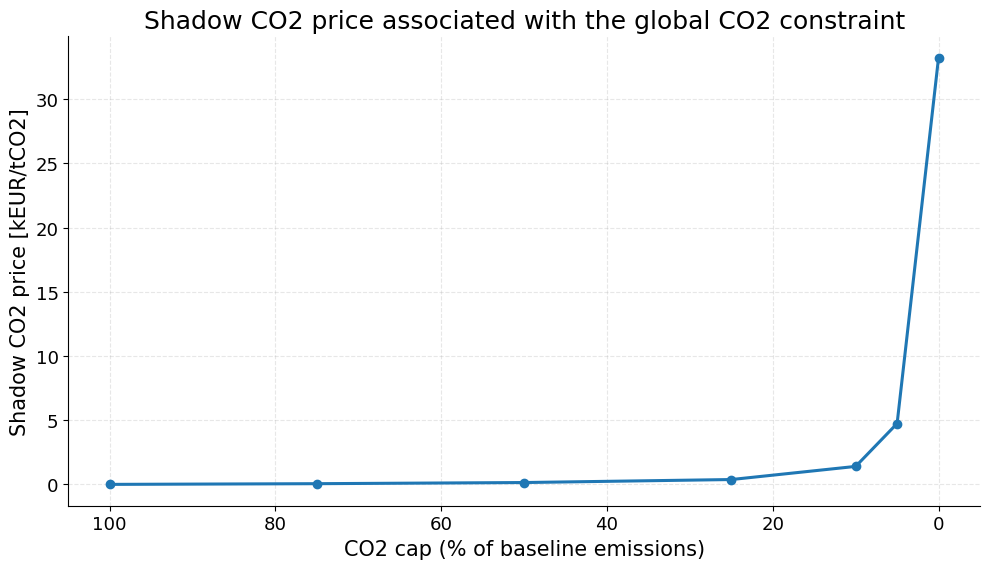

In [32]:
price_scale, price_unit = choose_scale(results_df["mu_co2_eur_per_tco2"], "currency")
fig, ax = plt.subplots(figsize=(10, 5.8))
ax.plot(
    results_df["co2_cap_share"] * 100,
    results_df["mu_co2_eur_per_tco2"] / price_scale,
    marker="o",
    linewidth=2.2,
    markersize=6,
)
ax.invert_xaxis()
ax.set_xlabel("CO2 cap (% of baseline emissions)", fontsize=15)
ax.set_ylabel(f"Shadow CO2 price [{price_unit}/tCO2]", fontsize=15)
ax.set_title("Shadow CO2 price associated with the global CO2 constraint", fontsize=18)
style_axes(ax)
fig.tight_layout()
fig.savefig(PLOTS_DIR / "section_f_shadow_co2_price.png", dpi=300)
plt.show()


# Section G
The interconnected electricity model is extended with a methane transport layer. 

Countries remain the same as Assignment 1.

Methane is represented through local gas buses, pipelines, and gas-to-power conversion.


### Assumptions


In [36]:
gas_pipeline_capacities_mw = {
    ("Germany", "Belgium"): 5000.0,
    ("Germany", "France"): 4600.0,
    ("Germany", "Netherlands"): 7500.0,
    ("Belgium", "France"): 6700.0,
    ("Belgium", "Netherlands"): 3750.0,
}

methane_supply_cost = {
    "Germany": 32.0,
    "Belgium": 34.0,
    "France": 36.0,
    "Netherlands": 28.0,
}

methane_supply_p_nom = {
    "Germany": 1e6,
    "Belgium": 1e6,
    "France": 1e6,
    "Netherlands": 1e6,
}

gas_efficiency = 0.39
methane_co2_t_per_mwh_th = 0.19
pipeline_efficiency = 1.0

### Network Build

In [ ]:
def build_interconnected_methane_model(
    country_data,
    line_capacities_mw,
    gas_pipeline_capacities_mw,
    methane_supply_cost_override=None,
):
    snapshots = country_data["Germany"]["load"].index

    network = pypsa.Network()
    network.set_snapshots(snapshots)

    methane_costs = methane_supply_cost.copy()
    if methane_supply_cost_override is not None:
        methane_costs.update(methane_supply_cost_override)

    # Carriers
    network.add("Carrier", "AC")
    network.add("Carrier", "onshorewind")
    network.add("Carrier", "offshorewind")
    network.add("Carrier", "solar")
    network.add("Carrier", "battery")
    network.add("Carrier", "residual")
    network.add("Carrier", "methane", co2_emissions=methane_co2_t_per_mwh_th)
    network.add("Carrier", "gas_pipeline")
    network.add("Carrier", "ocgt")

    # Techno-economic assumptions
    # Aligned with the Assignment 1.
    r = 0.07

    capex_onshore = 910000
    fom_onshore = 0.033
    lifetime_onshore = 30

    capex_offshore = 2506000
    fom_offshore = 0.03
    lifetime_offshore = 25

    capex_solar = 425000
    fom_solar = 0.03
    lifetime_solar = 25

    capex_gas = 560000
    fom_gas = 0.033
    lifetime_gas = 25

    capital_cost_onshore = annuity(lifetime_onshore, r) * capex_onshore * (1 + fom_onshore)
    capital_cost_offshore = annuity(lifetime_offshore, r) * capex_offshore * (1 + fom_offshore)
    capital_cost_solar = annuity(lifetime_solar, r) * capex_solar * (1 + fom_solar)
    capital_cost_gas = annuity(lifetime_gas, r) * capex_gas * (1 + fom_gas)

    n_bess = 15
    hmax = 6
    eta_ch = 0.90
    eta_dis = 0.90
    c_energy = 144600
    c_inverter = 310000
    fom_bess = 0.03

    battery_power_cost = annuity(n_bess, r) * (c_energy * hmax + c_inverter) * (1 + fom_bess)

    marginal_cost_onshore = 0.0
    marginal_cost_offshore = 0.0
    marginal_cost_solar = 0.0
    marginal_cost_battery = 0.0

    residual_marginal_cost = {
        "Belgium": 22.0,
        "France": 12.0,
        "Netherlands": 45.0,
    }

    # Electricity buses + gas buses
    for country in country_data.keys():
        network.add("Bus", country, carrier="AC", v_nom=400.0)
        network.add("Bus", f"{country}_gas", carrier="methane")

    # Loads
    for country in country_data.keys():
        network.add(
            "Load",
            f"load_{country}",
            bus=country,
            p_set=country_data[country]["load"],
        )


    # Germany extendable assets
    network.add(
        "Generator",
        "onshorewind_Germany",
        bus="Germany",
        carrier="onshorewind",
        p_nom_extendable=True,
        capital_cost=capital_cost_onshore,
        marginal_cost=marginal_cost_onshore,
        p_max_pu=country_data["Germany"]["cf_onshore"],
    )

    network.add(
        "Generator",
        "offshorewind_Germany",
        bus="Germany",
        carrier="offshorewind",
        p_nom_extendable=True,
        capital_cost=capital_cost_offshore,
        marginal_cost=marginal_cost_offshore,
        p_max_pu=country_data["Germany"]["cf_offshore"],
    )

    network.add(
        "Generator",
        "solar_Germany",
        bus="Germany",
        carrier="solar",
        p_nom_extendable=True,
        capital_cost=capital_cost_solar,
        marginal_cost=marginal_cost_solar,
        p_max_pu=country_data["Germany"]["cf_solar"],
    )

    network.add(
        "StorageUnit",
        "battery_Germany",
        bus="Germany",
        carrier="battery",
        p_nom_extendable=True,
        max_hours=hmax,
        efficiency_store=eta_ch,
        efficiency_dispatch=eta_dis,
        cyclic_state_of_charge=True,
        capital_cost=battery_power_cost,
        marginal_cost=marginal_cost_battery,
    )

    # Neighbour countries with fixed capacities
    for country in ["Belgium", "France", "Netherlands"]:
        caps = country_data[country]["capacities_mw"]

        network.add(
            "Generator",
            f"onshorewind_{country}",
            bus=country,
            carrier="onshorewind",
            p_nom=max(caps["wind_onshore"], 0.0),
            p_nom_extendable=False,
            marginal_cost=marginal_cost_onshore,
            p_max_pu=country_data[country]["cf_onshore"],
        )

        network.add(
            "Generator",
            f"offshorewind_{country}",
            bus=country,
            carrier="offshorewind",
            p_nom=max(caps["wind_offshore"], 0.0),
            p_nom_extendable=False,
            marginal_cost=marginal_cost_offshore,
            p_max_pu=country_data[country]["cf_offshore"],
        )

        network.add(
            "Generator",
            f"solar_{country}",
            bus=country,
            carrier="solar",
            p_nom=max(caps["solar"], 0.0),
            p_nom_extendable=False,
            marginal_cost=marginal_cost_solar,
            p_max_pu=country_data[country]["cf_solar"],
        )

        residual_series = country_data[country]["residual_generation"].clip(lower=0.0)
        residual_max = float(residual_series.max())

        if residual_max > 0:
            network.add(
                "Generator",
                f"residual_{country}",
                bus=country,
                carrier="residual",
                p_nom=residual_max,
                p_nom_extendable=False,
                marginal_cost=residual_marginal_cost[country],
                p_max_pu=(residual_series / residual_max).fillna(0.0),
            )

    # Local methane supply
    for country in country_data.keys():
        network.add(
            "Generator",
            f"methane_supply_{country}",
            bus=f"{country}_gas",
            carrier="methane",
            p_nom=methane_supply_p_nom[country],
            p_nom_extendable=False,
            marginal_cost=methane_costs[country],
            p_max_pu=1.0,
        )


    # Gas-to-power OCGT links
    network.add(
        "Link",
        "ocgt_Germany",
        bus0="Germany_gas",
        bus1="Germany",
        carrier="ocgt",
        p_nom_extendable=True,
        efficiency=gas_efficiency,
        capital_cost=capital_cost_gas / gas_efficiency,
        marginal_cost=0.0,
    )

    for country in ["Belgium", "France", "Netherlands"]:
        gas_capacity_el = max(country_data[country]["capacities_mw"]["gas"], 0.0)
        gas_capacity_th = gas_capacity_el / gas_efficiency if gas_capacity_el > 0 else 0.0

        network.add(
            "Link",
            f"ocgt_{country}",
            bus0=f"{country}_gas",
            bus1=country,
            carrier="ocgt",
            p_nom=gas_capacity_th,
            p_nom_extendable=False,
            efficiency=gas_efficiency,
            marginal_cost=0.0,
        )


    # Electricity lines
    for (bus0, bus1), cap in line_capacities_mw.items():
        network.add(
            "Line",
            f"{bus0}-{bus1}",
            bus0=bus0,
            bus1=bus1,
            s_nom=cap,
            s_nom_extendable=False,
            x=0.1,
        )


    # Methane pipelines
    for (c0, c1), cap in gas_pipeline_capacities_mw.items():
        network.add(
            "Link",
            f"pipe_{c0}_{c1}",
            bus0=f"{c0}_gas",
            bus1=f"{c1}_gas",
            carrier="gas_pipeline",
            p_nom=cap,
            p_nom_extendable=False,
            efficiency=pipeline_efficiency,
            marginal_cost=0.0,
            p_min_pu=-1.0,
        )

    return network


### Run Model


In [38]:
def solve_part_g_case(
    country_data,
    line_capacities_mw,
    gas_pipeline_capacities_mw,
    co2_cap_tonnes=None,
    solver_name=None,
    methane_supply_cost_override=None,
):
    if solver_name is None:
        solver_name = pick_solver()

    network = build_interconnected_methane_model(
        country_data,
        line_capacities_mw,
        gas_pipeline_capacities_mw,
        methane_supply_cost_override=methane_supply_cost_override,
    )

    if co2_cap_tonnes is not None:
        network.add(
            "GlobalConstraint",
            "co2_limit",
            type="primary_energy",
            carrier_attribute="co2_emissions",
            sense="<=",
            constant=co2_cap_tonnes,
        )

    def _to_object_index(idx):
        if hasattr(idx, "dtype") and str(idx.dtype).startswith("string"):
            return idx.astype("object")
        return idx

    for component in network.components.values():
        static = getattr(network, component.list_name, None)
        if static is None or static.empty:
            continue

        static.index = _to_object_index(static.index)
        static.columns = _to_object_index(static.columns)

        for col in static.columns:
            if str(static[col].dtype).startswith("string"):
                static[col] = static[col].astype("object")

    network.optimize(solver_name=solver_name)
    return network


In [ ]:
n_g = solve_part_g_case(
    country_data=country_data,
    line_capacities_mw=line_capacities_mw,
    gas_pipeline_capacities_mw=gas_pipeline_capacities_mw,
    co2_cap_tonnes=None,
    solver_name=SOLVER,
)

Index(['Germany-Belgium', 'Germany-France', 'Germany-Netherlands',
       'Belgium-France', 'Belgium-Netherlands'],
      dtype='object', name='name')
INFO:linopy.model: Solve problem using Highs solver
INFO:linopy.io:Writing objective.
Writing continuous variables.: 100%|██████████| 9/9 [00:00<00:00, 96.36it/s]
INFO:linopy.io: Writing time: 1.55s
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 316229 primals, 729077 duals
Objective: 5.27e+10
Solver model: available
Solver message: Optimal

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-fix-p-lower, Generator-fix-p-upper, Generator-ext-p-lower, Generator-ext-p-upper, Line-fix-s-lower, Line-fix-s-upper, Link-fix-p-lower, Link-fix-p-upper, Link-ext-p-lower, Link-ext-p-upper, StorageUnit-ext-p_dispatch-lower, StorageUnit-ext-p_dispatch-upper, StorageUnit-ext-p_store-lower, StorageUnit-ext-p_store-upper, StorageUnit-ext-state_of_charge-lower, StorageUnit-

Section g solved


# Section H

This section computes the implied CO2 price in the interconnected methane-electricity model for a selected decarbonisation target. 

The target is defined relative to the unconstrained baseline emissions of the Section G model.


### Selected Target


In [40]:
target_share = 0.50  # 50% emissions cap relative to the unconstrained baseline

### Run Model

In [41]:

n_h_baseline = solve_part_g_case(
    country_data=country_data,
    line_capacities_mw=line_capacities_mw,
    gas_pipeline_capacities_mw=gas_pipeline_capacities_mw,
    co2_cap_tonnes=None,
    solver_name=SOLVER,
)

baseline_methane = n_h_baseline.generators_t.p.filter(like="methane_supply").sum().sum()
baseline_emissions_h = baseline_methane * methane_co2_t_per_mwh_th
target_co2_cap = target_share * baseline_emissions_h

n_h = solve_part_g_case(
    country_data=country_data,
    line_capacities_mw=line_capacities_mw,
    gas_pipeline_capacities_mw=gas_pipeline_capacities_mw,
    co2_cap_tonnes=target_co2_cap,
    solver_name=SOLVER,
)

co2_price_h = -float(n_h.global_constraints.at["co2_limit", "mu"])

methane_h = n_h.generators_t.p.filter(like="methane_supply").sum().sum()
emissions_h = methane_h * methane_co2_t_per_mwh_th

print("\nSECTION H RESULTS")
print("Baseline emissions [tCO2]:", baseline_emissions_h)
print("Target CO2 cap share:", target_share)
print("Target CO2 cap [tCO2]:", target_co2_cap)
print("Actual emissions [tCO2]:", emissions_h)
print("Model CO2 price [EUR/tCO2]:", co2_price_h)

section_h_results = pd.DataFrame([{
    "baseline_emissions_tco2": baseline_emissions_h,
    "target_share": target_share,
    "target_co2_cap_tco2": target_co2_cap,
    "actual_emissions_tco2": emissions_h,
    "model_co2_price_eur_per_tco2": co2_price_h,
}])

section_h_results.to_csv(PLOTS_DIR / "section_h_co2_price_interconnected_model.csv", index=False)
print(section_h_results)


Index(['Germany-Belgium', 'Germany-France', 'Germany-Netherlands',
       'Belgium-France', 'Belgium-Netherlands'],
      dtype='object', name='name')
INFO:linopy.model: Solve problem using Highs solver
INFO:linopy.io:Writing objective.
Writing continuous variables.: 100%|██████████| 9/9 [00:00<00:00, 92.22it/s]
INFO:linopy.io: Writing time: 1.62s
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 316229 primals, 729077 duals
Objective: 5.27e+10
Solver model: available
Solver message: Optimal

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-fix-p-lower, Generator-fix-p-upper, Generator-ext-p-lower, Generator-ext-p-upper, Line-fix-s-lower, Line-fix-s-upper, Link-fix-p-lower, Link-fix-p-upper, Link-ext-p-lower, Link-ext-p-upper, StorageUnit-ext-p_dispatch-lower, StorageUnit-ext-p_dispatch-upper, StorageUnit-ext-p_store-lower, StorageUnit-ext-p_store-upper, StorageUnit-ext-state_of_charge-lower, StorageUnit-


SECTION H RESULTS
Baseline emissions [tCO2]: 51687140.76097033
Target CO2 cap share: 0.5
Target CO2 cap [tCO2]: 25843570.380485166
Actual emissions [tCO2]: 25843570.380484983
Model CO2 price [EUR/tCO2]: 190.7926908025745
   baseline_emissions_tco2  target_share  target_co2_cap_tco2  \
0             5.168714e+07           0.5         2.584357e+07   

   actual_emissions_tco2  model_co2_price_eur_per_tco2  
0           2.584357e+07                    190.792691  
